<h1 style="text-align:center; font-size:40px;"> Team 6 - TASK - 1 </h1>

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

## Importing the files (features and target) from https://archive.ics.uci.edu/dataset/2/adult

In [2]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
df_adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = df_adult.data.features 
Y = df_adult.data.targets 


### -- features table

In [4]:
X

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States


### -- target table

In [5]:
Y

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K
...,...
48837,<=50K.
48838,<=50K.
48839,<=50K.
48840,<=50K.


In [6]:
# Merging features and target table(X and Y)

df_adult = X.copy()
df_adult["income"] = Y.iloc[:, 0] 

In [7]:
df_adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


<p style="font-family: Cambria; font-size: 30px;"><b>
Problem Statement : Understand data and variables, define problem statement and ML flow. </p>

### Dataset Overview
The Adult Census Income dataset contains demographic, educational, and employment-related information collected from individuals. 
The dataset includes both numerical and categorical variables such as age, education level, workclass, occupation, marital status, 
hours worked per week, and native country. The target variable is **income**, which indicates whether an individual earns more than 
$50,000 per year. <br>

### Data Definition

<p style="font-family: Cambria; font-size: 16px;">

1. <b>age</b> - Age of the person and has no missing values. <br>

2. <b>workclass</b> - workclass indicates the type of employment or work arrangement under which an individual is employed, reflecting whether they work in the private sector, are self-employed, work for government, or are not employed. Categorical (Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.) <br>

3. <b>fnlwgt</b> - fnlwgt (Final Weight) represents the number of people in the population that each individual record represents, based on Census weighting adjustments. Integer - datatype. <br>

4. <b>education</b> - Highest level of education attained by the individual. Categorical 
(Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool) and has no missing values. <br>

5. <b>education-num</b> - Number of years of education corresponding to the education level. Integer datatype and has no missing values. <br>

6. <b>marital-status</b> - Marital status of the individual, describing their current marital condition. Categorical 
(Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse) and has no missing values. <br>

7. <b>occupation</b> - Type of occupation or job role of the individual. Categorical 
(Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces) and contains missing values. <br>

8. <b>relationship</b> - Relationship status within the household. Categorical 
(Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried) and has no missing values. <br>

9. <b>race</b> - Race of the individual. Categorical 
(White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black) and has no missing values. <br>

10. <b>sex</b> - Biological sex of the individual. Binary 
(Male, Female) and has no missing values. <br>

11. <b>capital-gain</b> - Capital gains earned by the individual. Integer datatype and has no missing values. <br>

12. <b>capital-loss</b> - Capital losses incurred by the individual. Integer datatype and has no missing values. <br>

13. <b>hours-per-week</b> - Number of hours worked per week by the individual. Integer datatype and has no missing values. <br>

14. <b>native-country</b> - Country of origin of the individual. Categorical 
(United-States and other countries) and contains missing values. <br>

15. <b>income</b> - Target variable indicating whether the individual's income exceeds $50K per year. Binary 
(>50K, <=50K) and has no missing values. <br>


### Variables Description
The dataset consists of multiple feature variables used for prediction and one target variable:
- Numerical features include age, education-num, capital-gain, capital-loss, hours-per-week, and fnlwgt.
- Categorical features include workclass, education, marital-status, occupation, relationship, race, sex, and native-country.
- The target variable **income** is binary, with values `>50K` and `<=50K`. <br> <br>



### Problem Statement

<p style="font-family: Cambria; font-size: 16px;">

1. The objective of this project is to analyze the Adult Census Income dataset to understand its variables and their relationship with income levels, and to build a machine learning classification model that predicts whether an individual’s annual income exceeds $50,000.

2. Using demographic, educational, and employment-related attributes, the model aims to identify patterns that distinguish higher-income individuals from lower-income individuals and accurately classify income levels for unseen data.

</p>

In [ ]:


### Machine Learning Flow

1. **Data Understanding**
   Explore the dataset to understand variables, data types, and identify the target variable.

2. **Initial Exploration**
   Inspect the first few rows using `head()` or `sample()`, examine column data types using `info()`, check for missing values, and review basic summary statistics using `describe()`.

3. **Hypothesis Generation**
   Formulate hypotheses based on domain knowledge and observed patterns in the data.

4. **Statistical Testing**
   Apply appropriate statistical tests to validate hypotheses and check for significant relationships between variables. Interpret p-values and understand Type I and Type II errors.

5. **Data Cleaning**
   Handle missing values, correct data types, and address data inconsistencies. Identify and treat outliers using techniques such as z-score or IQR.

6. **Univariate Analysis**
   Analyze individual variables using histograms, box plots, and bar charts to understand distributions and frequencies.

7. **Bivariate Analysis**
   Explore relationships between pairs of variables using scatter plots, box plots, and correlation analysis.

8. **Multivariate Analysis**
   Analyze interactions among multiple variables using heatmaps or pair plots.

9. **Feature Engineering**
   Encode categorical variables, transform numerical features, and create new features if required to improve model performance.

10. **Model Building and Evaluation**
    Train machine learning models such as Logistic Regression, Random Forest, SVM, or XGBoost, evaluate their performance, and summarize key findings.


<br>

# ML Flow chart

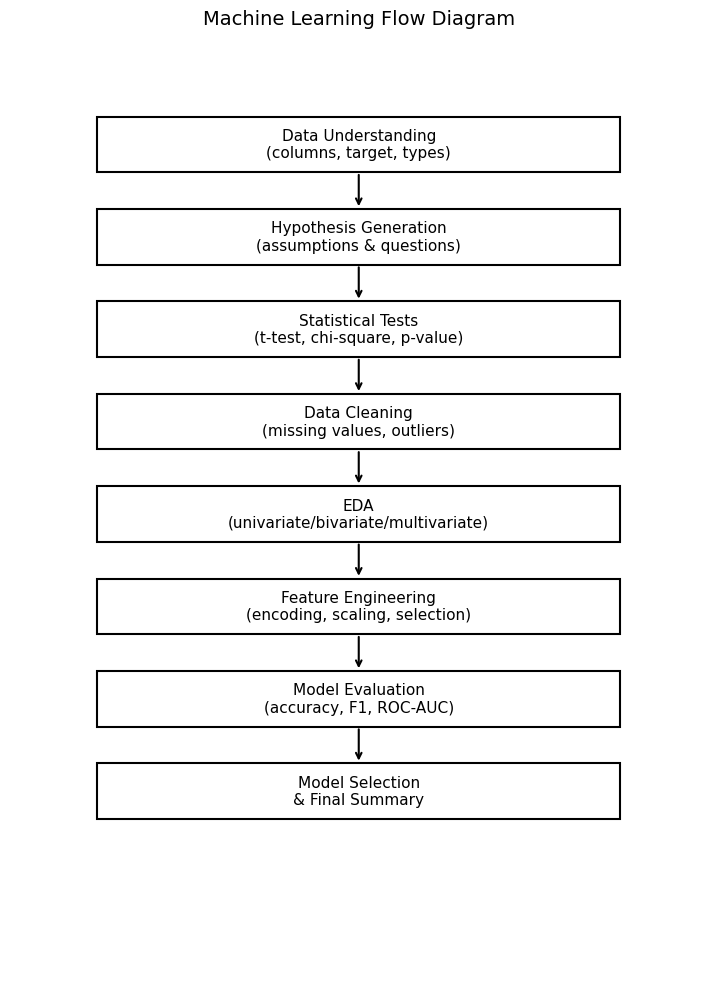

In [8]:
#Defining steps
def draw_ml_flow_diagram():
    steps = ["Data Understanding\n(columns, target, types)", "Hypothesis Generation\n(assumptions & questions)",
    "Statistical Tests\n(t-test, chi-square, p-value)", "Data Cleaning\n(missing values, outliers)",
        "EDA\n(univariate/bivariate/multivariate)", "Feature Engineering\n(encoding, scaling, selection)",
        "Model Evaluation\n(accuracy, F1, ROC-AUC)", "Model Selection\n& Final Summary"]

    fig, ax = plt.subplots(figsize=(9, 12))
    ax.axis("off")

# Layout parameters
    x = 0.5
    y_start = 0.9
    y_gap = 0.1
    box_width = 0.75
    box_height = 0.06

    y_positions = []

# Draw boxes
    for i, step in enumerate(steps):
        y = y_start - i * y_gap
        y_positions.append(y)

# Draw rectable box
        rect = plt.Rectangle(
            (x - box_width / 2, y - box_height / 2),
            box_width,
            box_height,
            fill=False,
            linewidth=1.5
        )
        ax.add_patch(rect)

        ax.text(x, y, step, ha="center", va="center", fontsize=11)

# Draw arrows
    for i in range(len(y_positions) - 1):
        ax.annotate("", xy=(x, y_positions[i + 1] + box_height / 2), xytext=(x, y_positions[i] - box_height / 2),
            arrowprops=dict(arrowstyle="->", linewidth=1.5))

    ax.set_title("Machine Learning Flow Diagram", fontsize=14, pad=20)
    plt.show()

# Call the function
draw_ml_flow_diagram()


### Exporting file into csv

In [9]:
df_adult.to_csv("adult_ml.csv", index=False)

#  Task2

###  Initial Exploration: Check the first few rows of the dataset using the head() or sample() function  to get an overview of the data. Examine the columns and their data types using info(). Check for  missing values using isnull() or info(). Investigate basic summary statistics with describe().

In [13]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [14]:
df_adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [15]:
df_adult.tail()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.
48841,35,Self-emp-inc,182148,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,>50K.


In [17]:
df_adult.shape


(48842, 15)

In [18]:
df_adult.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [22]:
df_adult.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

Column Types:
Numerical: age,fnlwgt,education-num ,capital-gain,capital-loss,hoursperweek

Categorical:
workclass(contain some special characters like - ? and blanks),
maritalstatus(contain sepcial characters like -),
occupation(contain special characters like - ? and blanks),
relationship(contain special characters like -),
race(contain special characters like -),
sex,
native-country(contain special characters like - ? () and blanks)

Mixed:education,income

In [24]:
df_adult.sample()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
7287,35,Private,164526,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,40,Yugoslavia,>50K


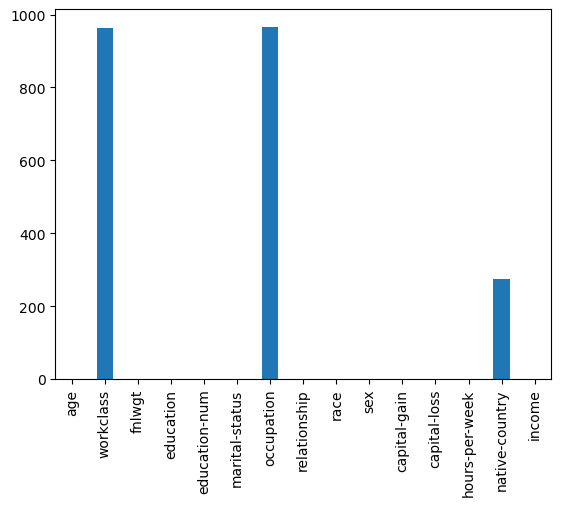

In [25]:
df_adult.isnull().sum().plot.bar()
plt.show()

In [27]:
df_adult.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

In [29]:
df_adult['age'].value_counts()

age
36    1348
35    1337
33    1335
23    1329
31    1325
      ... 
88       6
85       5
87       3
89       2
86       1
Name: count, Length: 74, dtype: int64

In [31]:
df_adult['workclass'].value_counts()

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

C:\Users\garin\AppData\Local\Temp\ipykernel_22116\2853273766.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_adult['workclass'], palette='magma')


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'State-gov'),
  Text(1, 0, 'Self-emp-not-inc'),
  Text(2, 0, 'Private'),
  Text(3, 0, 'Federal-gov'),
  Text(4, 0, 'Local-gov'),
  Text(5, 0, '?'),
  Text(6, 0, 'Self-emp-inc'),
  Text(7, 0, 'Without-pay'),
  Text(8, 0, 'Never-worked')])

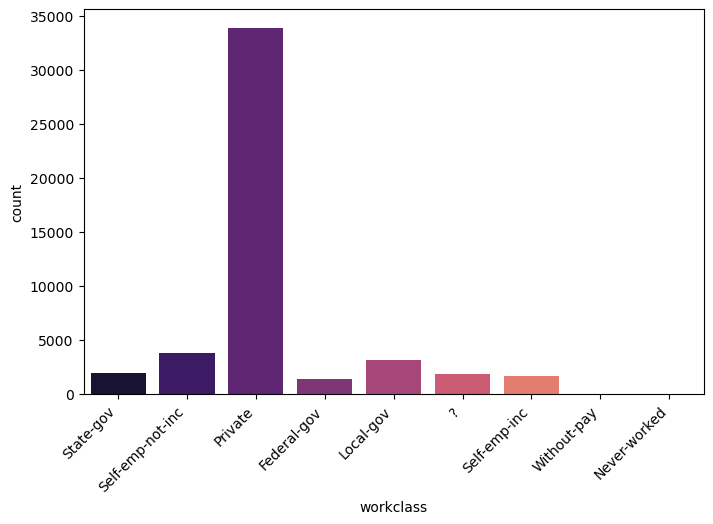

In [34]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.countplot(x=df_adult['workclass'], palette='magma')
plt.xticks(rotation=45, ha='right')

In [40]:
df_adult['income'].value_counts()

income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

“The income column contained duplicate categories caused by trailing punctuation, such as <=50K and <=50K.. To ensure consistency, I cleaned the column by stripping whitespace and removing trailing periods. This standardized the categories and prevented the model from treating them as separate classes.”

In [42]:
df_adult['income'] = (
    df_adult['income']
    .str.strip()
    .str.replace('.', '', regex=False)
    .str.replace(' ', '', regex=False)
    .astype('category')
)


In [43]:
df_adult['income'].value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

C:\Users\garin\AppData\Local\Temp\ipykernel_22116\4179541976.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_adult['income'], palette='magma')


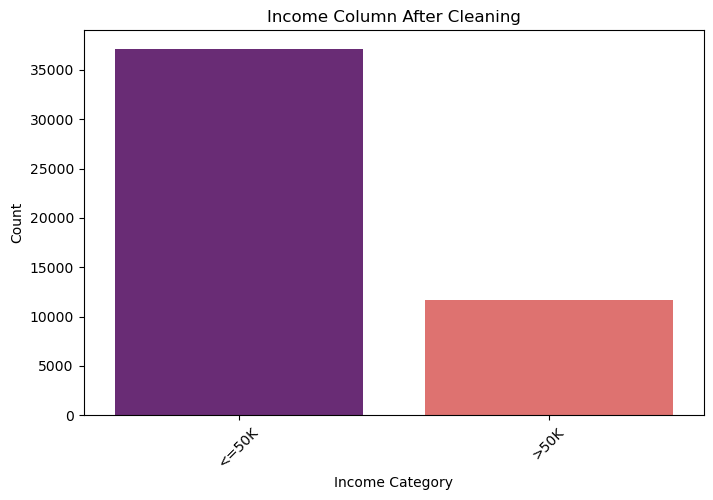

In [45]:

plt.figure(figsize=(8,5))
sns.countplot(x=df_adult['income'], palette='magma')
plt.title("Income Column After Cleaning")
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Task3 :Generate Hypothesis: Define Hypothesis statements

In [35]:
# Build a clean hypothesis table (null/alternative) for the Adult Income dataset
import pandas as pd

hypothesis_rows = [
    {
        "ID": "H1",
        "Feature(s)": "education-num (or education)",
        "Type": "Numeric / Categorical",
        "Business intuition": "Higher education is linked to higher-paying occupations and wages.",
        "H0 (null)": "Income class is independent of education level.",
        "H1 (alternative)": "Higher education level increases the likelihood of income >50K.",
        "How to test (EDA / stats / ML)": "Compare >50K rate by education; trend vs education-num; chi-square for education; logistic coef / SHAP for direction.",
        "Expected direction": "+"
    },
    {
        "ID": "H2",
        "Feature(s)": "age",
        "Type": "Numeric",
        "Business intuition": "Income often rises with experience and seniority.",
        "H0 (null)": "Income class is independent of age.",
        "H1 (alternative)": "Higher age is associated with higher likelihood of income >50K.",
        "How to test (EDA / stats / ML)": "Plot >50K rate by age bins; t-test/KS test on age by class; model partial dependence.",
        "Expected direction": "+"
    },
    {
        "ID": "H3",
        "Feature(s)": "hours-per-week",
        "Type": "Numeric",
        "Business intuition": "More work hours often correspond to full-time/professional roles.",
        "H0 (null)": "Income class is independent of hours worked per week.",
        "H1 (alternative)": "More hours-per-week increases the likelihood of income >50K.",
        "How to test (EDA / stats / ML)": "Boxplots by class; compare means/medians; fit logistic with hours; check monotonic pattern.",
        "Expected direction": "+"
    },
    {
        "ID": "H4",
        "Feature(s)": "capital-gain",
        "Type": "Numeric",
        "Business intuition": "Investment gains are more common among higher-income individuals.",
        "H0 (null)": "Income class is independent of capital-gain.",
        "H1 (alternative)": "Higher (or non-zero) capital-gain increases likelihood of income >50K.",
        "How to test (EDA / stats / ML)": "Compare >50K rate for capital-gain=0 vs >0; log-transform then compare; model importance.",
        "Expected direction": "+ (strong)"
    },
    {
        "ID": "H5",
        "Feature(s)": "occupation",
        "Type": "Categorical",
        "Business intuition": "Different occupations have very different pay scales.",
        "H0 (null)": "Income class distribution is the same across occupations.",
        "H1 (alternative)": "Income class distribution differs by occupation.",
        "How to test (EDA / stats / ML)": "Bar chart of >50K rate by occupation; chi-square test; model coefficients per category.",
        "Expected direction": "Varies by category"
    },
    {
        "ID": "H6",
        "Feature(s)": "marital-status",
        "Type": "Categorical",
        "Business intuition": "Marital status correlates with household structure, age, and earnings.",
        "H0 (null)": "Income class distribution is the same across marital-status categories.",
        "H1 (alternative)": "Income class distribution differs by marital-status.",
        "How to test (EDA / stats / ML)": "Bar chart of >50K rate by marital-status; chi-square; check model category effects.",
        "Expected direction": "Varies by category"
    },
    {
        "ID": "H7",
        "Feature(s)": "workclass",
        "Type": "Categorical",
        "Business intuition": "Employer type (private/government/self-employed) can affect pay bands.",
        "H0 (null)": "Income class distribution is the same across workclass.",
        "H1 (alternative)": "Income class distribution differs by workclass.",
        "How to test (EDA / stats / ML)": "Bar chart of >50K rate by workclass; chi-square; model category weights.",
        "Expected direction": "Varies by category"
    },
    {
        "ID": "H8",
        "Feature(s)": "sex",
        "Type": "Categorical (sensitive)",
        "Business intuition": "Historical wage gaps may be reflected in the data.",
        "H0 (null)": "Income class distribution is the same across sex categories.",
        "H1 (alternative)": "Income class distribution differs across sex categories.",
        "How to test (EDA / stats / ML)": "Compare >50K rates by sex; chi-square; fairness metrics (TPR/FPR parity) after modeling.",
        "Expected direction": "Difference expected (bias risk)"
    },
    {
        "ID": "H9",
        "Feature(s)": "race",
        "Type": "Categorical (sensitive)",
        "Business intuition": "Historical inequities may appear in outcomes.",
        "H0 (null)": "Income class distribution is the same across race categories.",
        "H1 (alternative)": "Income class distribution differs across race categories.",
        "How to test (EDA / stats / ML)": "Compare >50K rates by race; chi-square; fairness checks on model errors by group.",
        "Expected direction": "Difference expected (bias risk)"
    },
    {
        "ID": "H10",
        "Feature(s)": "education-num × hours-per-week",
        "Type": "Interaction",
        "Business intuition": "Extra hours may pay off more in higher-skill roles.",
        "H0 (null)": "No interaction: the effect of hours-per-week does not change with education.",
        "H1 (alternative)": "Interaction exists: the effect of hours-per-week on >50K probability depends on education.",
        "How to test (EDA / stats / ML)": "Fit logistic with interaction term; compare AUC/F1; plot partial dependence for hours at different education levels.",
        "Expected direction": "Stronger + effect at higher education"
    }
]

hypothesis_table_df = pd.DataFrame(hypothesis_rows)
print(hypothesis_table_df)

    ID                      Feature(s)                     Type  \
0   H1    education-num (or education)    Numeric / Categorical   
1   H2                             age                  Numeric   
2   H3                  hours-per-week                  Numeric   
3   H4                    capital-gain                  Numeric   
4   H5                      occupation              Categorical   
5   H6                  marital-status              Categorical   
6   H7                       workclass              Categorical   
7   H8                             sex  Categorical (sensitive)   
8   H9                            race  Categorical (sensitive)   
9  H10  education-num × hours-per-week              Interaction   

                                  Business intuition  \
0  Higher education is linked to higher-paying oc...   
1  Income often rises with experience and seniority.   
2  More work hours often correspond to full-time/...   
3  Investment gains are more common am

In [36]:
hypothesis_table_df.to_csv("Hypothesis_statements.csv", index=False)

## Task4: Statistical Tests :
Perform statistical tests to validate hypotheses or check for significant differences between groups.
Explain Hypothesis Testing and p-value.What are type 1 and Type 2 errors?and 
apply Statistical test on generated hypothesis

In [53]:
import pandas as pd
from scipy.stats import chi2_contingency


#df = pd.read_csv(url, names=cols, sep=', ', engine='python')

# Step 1: Build the contingency table
contingency_edutable = pd.crosstab(df_adult['education'], df_adult['income'])
print(contingency_table)

# Step 2: Run Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic : {chi2:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"P-value              : {p_value:.6f}")

# Step 3: Decision
alpha = 0.05
if p_value < alpha:
    print("\nReject H₀ — Income class is NOT independent of education level.")
else:
    print("\nFail to reject H₀ — No significant association found.")

income        <=50K  >50K
education                
10th           1302    87
11th           1720    92
12th            609    48
1st-4th         239     8
5th-6th         482    27
7th-8th         893    62
9th             715    41
Assoc-acdm     1188   413
Assoc-voc      1539   522
Bachelors      4712  3313
Doctorate       163   431
HS-grad       13281  2503
Masters        1198  1459
Preschool        82     1
Prof-school     217   617
Some-college   8815  2063

Chi-Square Statistic : 6537.9730
Degrees of Freedom   : 15
P-value              : 0.000000

Reject H₀ — Income class is NOT independent of education level.


# Cramér’s V is an effect‑size measure for two categorical variables.

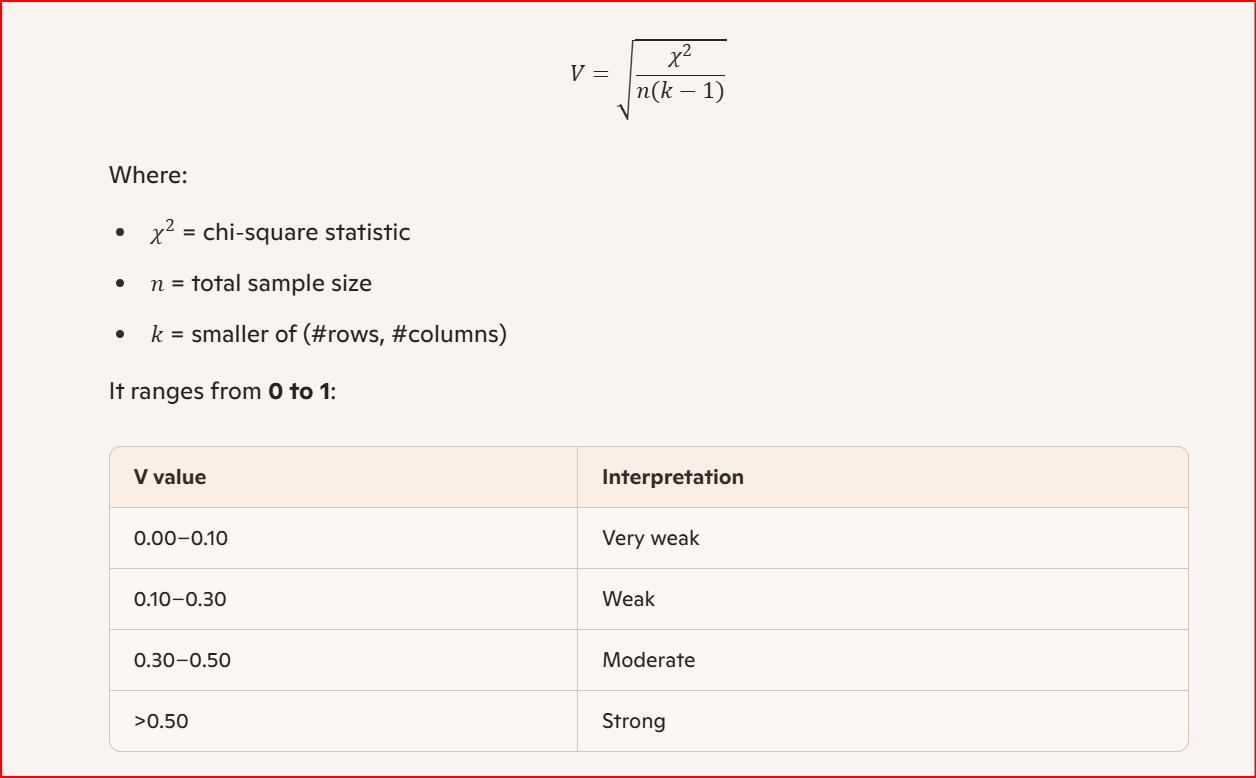

In [56]:
from IPython.display import Image
Image(filename='cramers rule.png')


In [54]:
import numpy as np

n = contingency_edutable.values.sum()      # total observations
min_dim = min(contingency_edutable.shape) - 1  # min(rows-1, cols-1)

cramers_vedu = np.sqrt(chi2 / (n * min_dim))
print(f"Cramér's V_edu: {cramers_vedu:.4f}")

Cramér's V_edu: 0.3659


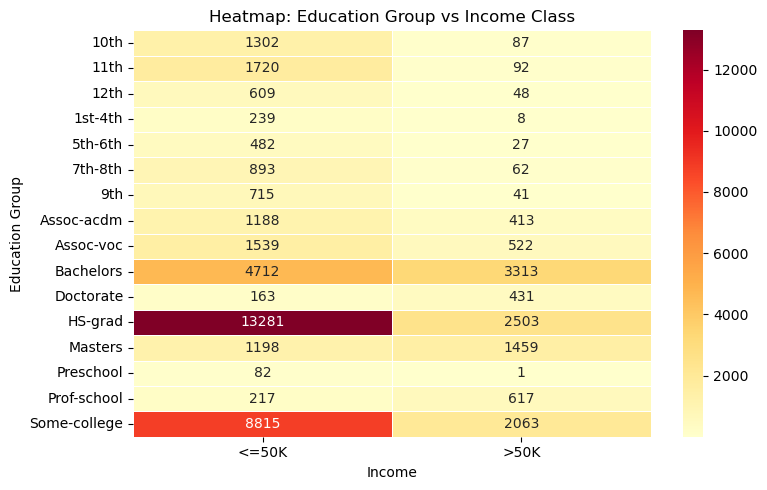

In [55]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.heatmap(contingency_edutable, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5)

plt.title('Heatmap: Education Group vs Income Class')
plt.xlabel('Income')
plt.ylabel('Education Group')
plt.tight_layout()
plt.show()

C:\Users\garin\AppData\Local\Temp\ipykernel_22116\617729316.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Income')


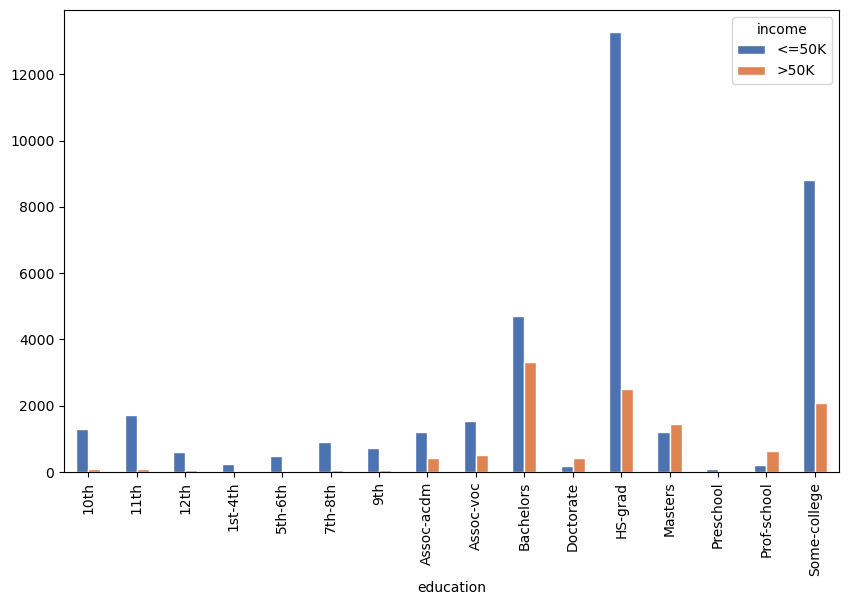

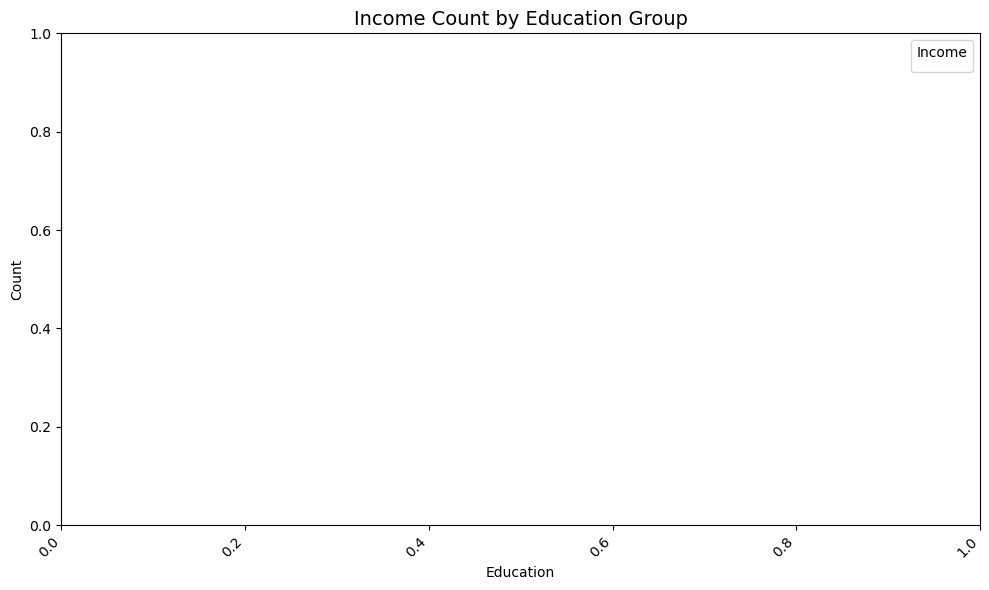

In [57]:
contingency_edutable.plot(kind='bar', figsize=(10, 6),
                       color=['#4C72B0', '#DD8452'], edgecolor='white')

# Step 1: Create figure and ax FIRST
fig, ax = plt.subplots(figsize=(10, 6))
# Calculate row-wise percentages (% within each education group)
row_totals = contingency_edutable.sum(axis=1)
pct_table = contingency_edutable.div(row_totals, axis=0) * 100

# Add % labels on each bar
for i, container in enumerate(ax.containers):
    for j, bar in enumerate(container):
        height = bar.get_height()
        if height > 0:
            # Get the % value for this bar (i = income class, j = education group)
            pct = pct_table.iloc[j, i]
            ax.text(
                bar.get_x() + bar.get_width() / 2,  # x: center of bar
                height + 50,                          # y: just above bar top
                f'{pct:.1f}%',                        # label format
                ha='center', va='bottom',
                fontsize=9, fontweight='bold'
            )

plt.title('Income Count by Education Group', fontsize=14)
plt.xlabel('Education')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Income')
plt.tight_layout()
plt.show()

In [59]:
import pandas as pd
from scipy.stats import chi2_contingency


#df = pd.read_csv(url, names=cols, sep=', ', engine='python')

# Step 1: Build the contingency table
contingency_agetable = pd.crosstab(df_adult['age'], df_adult['income'])
print(contingency_agetable)

# Step 2: Run Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(contingency_agetable)

print(f"\nChi-Square Statistic : {chi2:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"P-value              : {p_value:.6f}")

# Step 3: Decision
alpha = 0.05
if p_value < alpha:
    print("\nReject H₀ — Income is NOT independent of age.")
else:
    print("\nFail to reject H₀ — No significant association found.")

income  <=50K  >50K
age                
17        595     0
18        862     0
19       1050     3
20       1112     1
21       1090     6
..        ...   ...
86          1     0
87          3     0
88          5     1
89          2     0
90         42    13

[74 rows x 2 columns]

Chi-Square Statistic : 5177.5819
Degrees of Freedom   : 73
P-value              : 0.000000

Reject H₀ — Income is NOT independent of age.


 The chi-square statistic is sensitive to sample size (large samples inflate it). To measure actual strength of the association, use Cramér's V

In [60]:
import numpy as np

n = contingency_agetable.values.sum()      # total observations
min_dim = min(contingency_agetable.shape) - 1  # min(rows-1, cols-1)

cramers_v_age = np.sqrt(chi2 / (n * min_dim))
print(f"Cramér's V_age: {cramers_v_age:.4f}")

Cramér's V_age: 0.3256


# Task5 Data Cleaning:
Handle missing values by either removing rows or filling them with appropriate values (mean, median, mode, etc.). Correct data types if needed. Address any outliers or anomalies.   "Outlier Detection and Treatment: 
Identify and handle outliers using techniques like z-scores, IQR, or domain knowledge.   

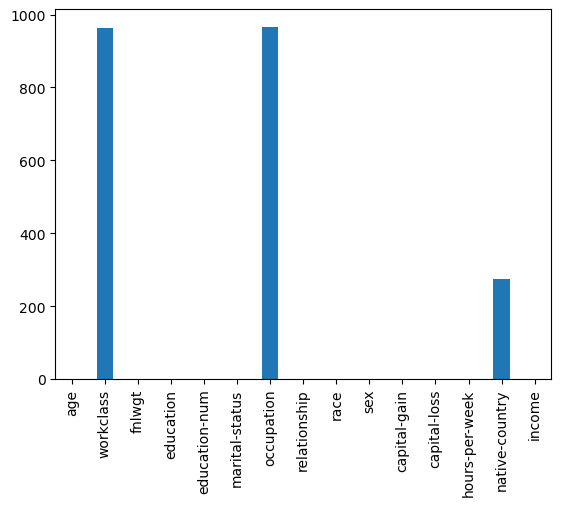

In [65]:
import matplotlib.pyplot as plt
df_adult.isnull().sum().plot.bar()
plt.show()

In [67]:
import pandas as pd

df_adult['age_bin'] = pd.cut(
    df_adult['age'],
    bins=[0, 25, 35, 50, 65, 100],
    labels=['Young (≤25)', 'Early Career (26–35)', 'Mid Career (36–50)',
            'Late Career (51–65)', 'Senior (65+)']
)


C:\Users\garin\AppData\Local\Temp\ipykernel_22116\3409679424.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_adult['age_bin'], palette='magma')


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Young (≤25)'),
  Text(1, 0, 'Early Career (26–35)'),
  Text(2, 0, 'Mid Career (36–50)'),
  Text(3, 0, 'Late Career (51–65)'),
  Text(4, 0, 'Senior (65+)')])

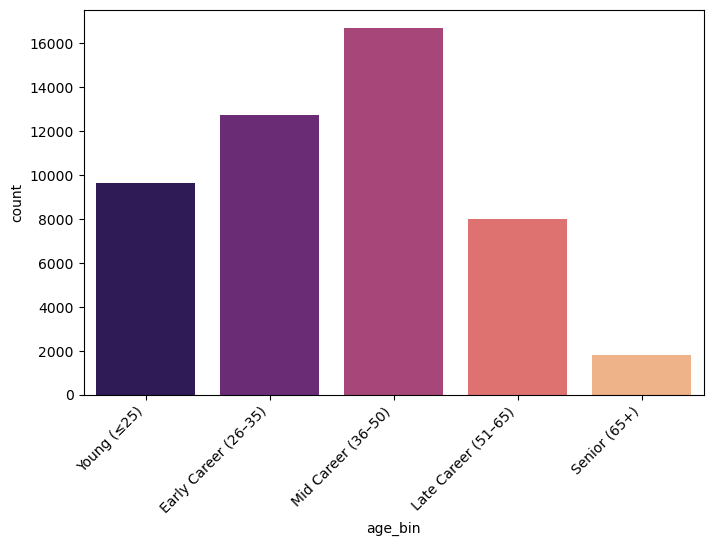

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x=df_adult['age_bin'], palette='magma')
plt.xticks(rotation=45, ha='right')

In [71]:
df_adult['workclass'].value_counts()

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

C:\Users\garin\AppData\Local\Temp\ipykernel_22116\3636890650.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_adult['workclass'], palette='magma')


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'State-gov'),
  Text(1, 0, 'Self-emp-not-inc'),
  Text(2, 0, 'Private'),
  Text(3, 0, 'Federal-gov'),
  Text(4, 0, 'Local-gov'),
  Text(5, 0, '?'),
  Text(6, 0, 'Self-emp-inc'),
  Text(7, 0, 'Without-pay'),
  Text(8, 0, 'Never-worked')])

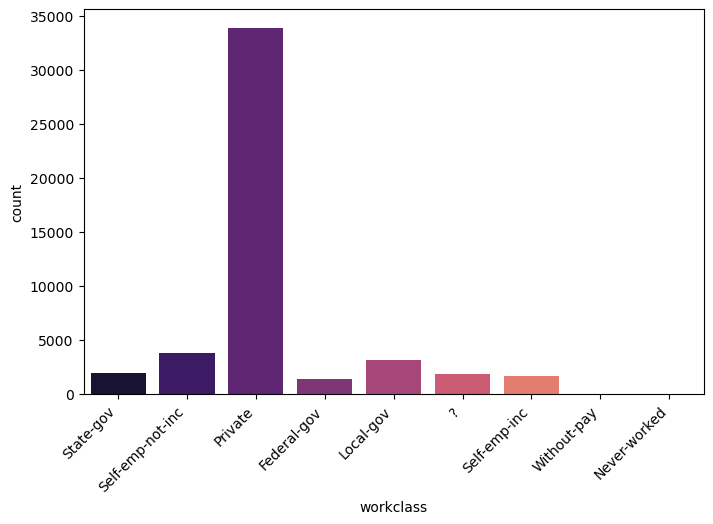

In [73]:
plt.figure(figsize=(8,5))
sns.countplot(x=df_adult['workclass'], palette='magma')
plt.xticks(rotation=45, ha='right')

In [75]:
df_adult['workclass'] = df_adult['workclass'].fillna('Unknown')


In [79]:
df_adult['workclass'].value_counts()

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
Unknown              2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

In [78]:
df_adult['workclass'] = df_adult['workclass'].replace('?','Unknown')


In [80]:
df_adult['workclass'].value_counts()

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
Unknown              2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

In [81]:
df_adult['workclass'] = df_adult['workclass'].replace({
    'Private': 'Private',
    'Self-emp-not-inc': 'Self-employed',
    'Self-emp-inc': 'Self-employed',
    'Local-gov': 'Government',
    'State-gov': 'Government',
    'Federal-gov': 'Government',
    'Without-pay': 'Other',
    'Never-worked': 'Other',
      
})


In [82]:
df_adult['workclass'].value_counts()

workclass
Private          33906
Government        6549
Self-employed     5557
Unknown           2799
Other               31
Name: count, dtype: int64

C:\Users\garin\AppData\Local\Temp\ipykernel_22116\3636890650.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_adult['workclass'], palette='magma')


([0, 1, 2, 3],
 [Text(0, 0, 'Government'),
  Text(1, 0, 'Self-employed'),
  Text(2, 0, 'Private'),
  Text(3, 0, 'Other')])

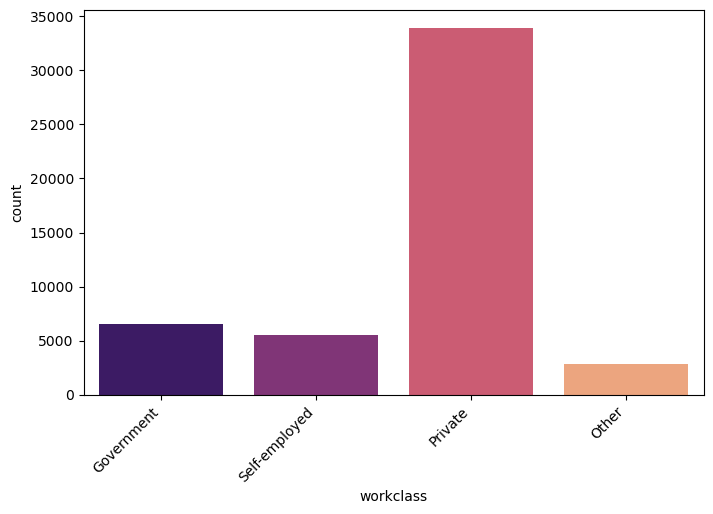

In [87]:
plt.figure(figsize=(8,5))
sns.countplot(x=df_adult['workclass'], palette='magma')
plt.xticks(rotation=45, ha='right')

In [86]:
df_adult['workclass'] = df_adult['workclass'].replace('Unknown','Other')

“The income column contained duplicate categories caused by trailing punctuation, such as <=50K and <=50K.. To ensure consistency, we cleaned the column by stripping whitespace and removing trailing periods. This standardized the categories and prevented the model from treating them as separate classes.”

In [90]:
df_adult['education-num'].value_counts()

education-num
9     15784
10    10878
13     8025
14     2657
11     2061
7      1812
12     1601
6      1389
4       955
15      834
5       756
8       657
16      594
3       509
2       247
1        83
Name: count, dtype: int64

<Axes: xlabel='education-num', ylabel='count'>

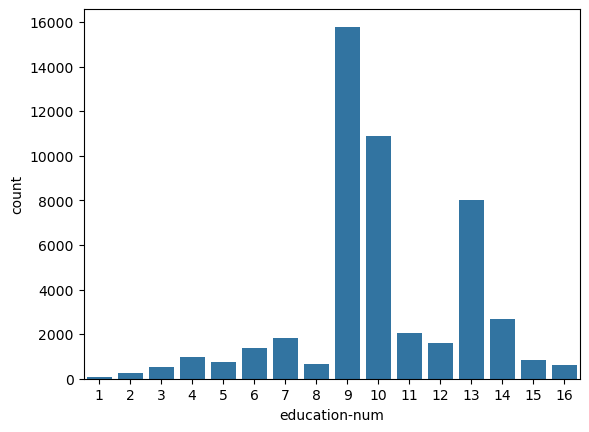

In [91]:
sns.countplot(x=df_adult['education-num'])


In [93]:
df_adult.groupby(['education', 'education-num']).size()


education     education-num
10th          6                 1389
11th          7                 1812
12th          8                  657
1st-4th       2                  247
5th-6th       3                  509
7th-8th       4                  955
9th           5                  756
Assoc-acdm    12                1601
Assoc-voc     11                2061
Bachelors     13                8025
Doctorate     16                 594
HS-grad       9                15784
Masters       14                2657
Preschool     1                   83
Prof-school   15                 834
Some-college  10               10878
dtype: int64

In [94]:
edu_map = {
    1: 'Preschool',
    2: '1st-4th',
    3: '5th-6th',
    4: '7th-8th',
    5: '9th',
    6: '10th',
    7: '11th',
    8: '12th',
    9: 'HS-grad',
    10: 'Some-college',
    11: 'Assoc-voc',
    12: 'Assoc-acdm',
    13: 'Bachelors',
    14: 'Masters',
    15: 'Prof-school',
    16: 'Doctorate'
}

df_adult['education_clean'] = df_adult['education-num'].map(edu_map)


In [97]:
df_adult['education_group'] = pd.cut(
    df_adult['education-num'],
    bins=[0, 9, 13, 16],
    labels=['Low Education', 'Undergrad Level', 'Graduate Level']
)


<Axes: xlabel='education_group', ylabel='count'>

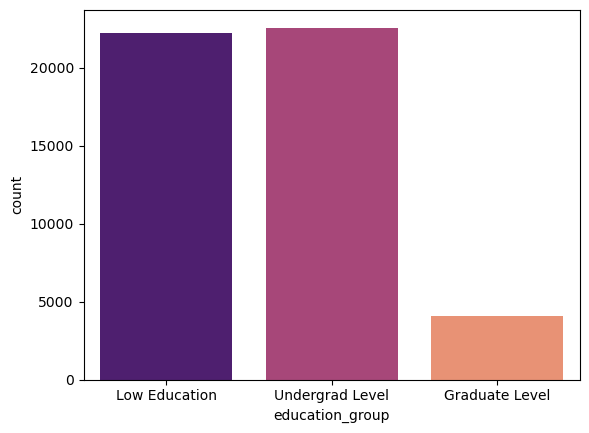

In [98]:
sns.countplot(data=df_adult, x='education_group', hue='education_group', palette='magma', legend=False)


In [100]:
df_adult['marital-status'].value_counts()

marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

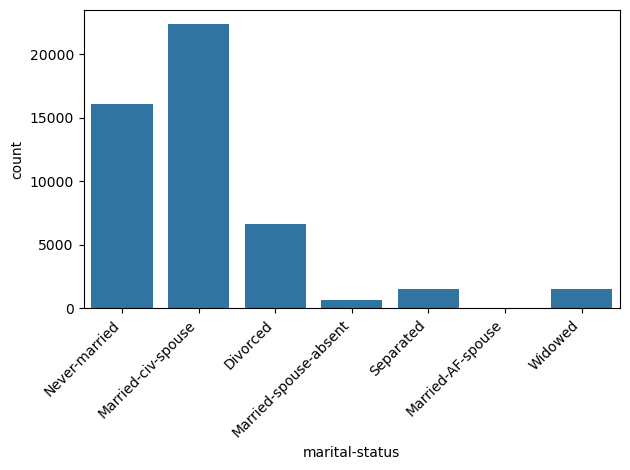

In [101]:
sns.countplot(x='marital-status', data=df_adult)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [102]:
df_adult['marital_group'] = df_adult['marital-status'].replace({
    'Married-civ-spouse': 'Married',
    'Married-AF-spouse': 'Married',
    'Married-spouse-absent': 'Married',
    'Never-married': 'Never-married',
    'Divorced': 'Previously-married',
    'Separated': 'Previously-married',
    'Widowed': 'Previously-married'
})


<Axes: xlabel='marital_group', ylabel='count'>

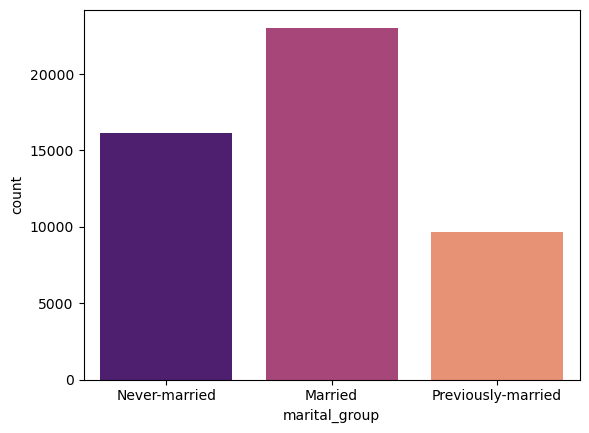

In [103]:
sns.countplot(data=df_adult, x='marital_group', hue='marital_group', palette='magma', legend=False)


In [105]:
df_adult['occupation'].value_counts()

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Transport-moving     2355
Handlers-cleaners    2072
?                    1843
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

In [107]:
df_adult.groupby(['workclass', 'occupation']).size()

workclass      occupation       
Government     Adm-clerical         1283
               Armed-Forces           15
               Craft-repair          398
               Exec-managerial       886
               Farming-fishing        77
               Handlers-cleaners     120
               Machine-op-inspct      62
               Other-service         546
               Prof-specialty       1943
               Protective-serv       672
               Sales                  53
               Tech-support          241
               Transport-moving      253
Other          ?                    1843
               Adm-clerical            3
               Craft-repair            1
               Exec-managerial         1
               Farming-fishing         8
               Handlers-cleaners       2
               Machine-op-inspct       2
               Other-service           2
               Sales                   1
               Transport-moving        1
Private        Adm-cleri

In [109]:
occupation_map = {
    'Exec-managerial': 'Management',
    'Prof-specialty': 'Professional',
    'Tech-support': 'Technical',
    'Adm-clerical': 'Clerical',

    'Craft-repair': 'Skilled Labor',
    'Machine-op-inspct': 'Skilled Labor',

    'Handlers-cleaners': 'Labor',
    'Transport-moving': 'Labor',

    'Farming-fishing': 'Agriculture',

    'Sales': 'Sales',

    'Other-service': 'Service',
    'Protective-serv': 'Service',
    'Priv-house-serv': 'Service',

    'Armed-Forces': 'Military',

    '?': 'Unknown'
}

df_adult['occupation_grouped'] = df_adult['occupation'].map(occupation_map)


In [111]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   age                 48842 non-null  int64   
 1   workclass           48842 non-null  object  
 2   fnlwgt              48842 non-null  int64   
 3   education           48842 non-null  object  
 4   education-num       48842 non-null  int64   
 5   marital-status      48842 non-null  object  
 6   occupation          47876 non-null  object  
 7   relationship        48842 non-null  object  
 8   race                48842 non-null  object  
 9   sex                 48842 non-null  object  
 10  capital-gain        48842 non-null  int64   
 11  capital-loss        48842 non-null  int64   
 12  hours-per-week      48842 non-null  int64   
 13  native-country      48568 non-null  object  
 14  income              48842 non-null  category
 15  age_bin             48842 non-null  

In [112]:
df_adult['native-country'].value_counts()

native-country
United-States                 43832
Mexico                          951
?                               583
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Greece                           49
Nicaragua                        49
Peru         

In [114]:
region_map = {
    # North America
    'United-States': 'North America',
    'Canada': 'North America',
    'Mexico': 'North America',
    'Puerto-Rico': 'North America',
    'Outlying-US(Guam-USVI-etc)': 'North America',

    # Central & South America
    'El-Salvador': 'Central/South America',
    'Guatemala': 'Central/South America',
    'Nicaragua': 'Central/South America',
    'Honduras': 'Central/South America',
    'Ecuador': 'Central/South America',
    'Peru': 'Central/South America',
    'Columbia': 'Central/South America',
    'Haiti': 'Central/South America',
    'Dominican-Republic': 'Central/South America',
    'Jamaica': 'Central/South America',
    'Trinadad&Tobago': 'Central/South America',

    # Europe
    'England': 'Europe',
    'Germany': 'Europe',
    'Italy': 'Europe',
    'Poland': 'Europe',
    'Portugal': 'Europe',
    'France': 'Europe',
    'Ireland': 'Europe',
    'Scotland': 'Europe',
    'Greece': 'Europe',
    'Hungary': 'Europe',
    'Yugoslavia': 'Europe',
    'Holand-Netherlands': 'Europe',

    # Asia
    'India': 'Asia',
    'China': 'Asia',
    'Japan': 'Asia',
    'Philippines': 'Asia',
    'Vietnam': 'Asia',
    'Thailand': 'Asia',
    'Taiwan': 'Asia',
    'Cambodia': 'Asia',
    'Laos': 'Asia',
    'Hong': 'Asia',
    'Iran': 'Asia',

    # Unknown
    '?': 'Unknown'
}

df_adult['native_country_grouped'] = df_adult['native-country'].map(region_map).fillna('Other')


In [115]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   age                     48842 non-null  int64   
 1   workclass               48842 non-null  object  
 2   fnlwgt                  48842 non-null  int64   
 3   education               48842 non-null  object  
 4   education-num           48842 non-null  int64   
 5   marital-status          48842 non-null  object  
 6   occupation              47876 non-null  object  
 7   relationship            48842 non-null  object  
 8   race                    48842 non-null  object  
 9   sex                     48842 non-null  object  
 10  capital-gain            48842 non-null  int64   
 11  capital-loss            48842 non-null  int64   
 12  hours-per-week          48842 non-null  int64   
 13  native-country          48568 non-null  object  
 14  income                

In [123]:
df_adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,...,capital-loss,hours-per-week,native-country,income,age_bin,education_clean,education_group,marital_group,occupation_grouped,native_country_grouped
0,39,Government,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,...,0,40,United-States,<=50K,Mid Career (36–50),Bachelors,Undergrad Level,Never-married,Clerical,North America
1,50,Self-employed,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,...,0,13,United-States,<=50K,Mid Career (36–50),Bachelors,Undergrad Level,Married,Management,North America
2,38,Private,215646,HS-grad,9,Other,Handlers-cleaners,Not-in-family,White,Male,...,0,40,United-States,<=50K,Mid Career (36–50),HS-grad,Low Education,Previously-married,Labor,North America
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,...,0,40,United-States,<=50K,Late Career (51–65),11th,Low Education,Married,Labor,North America
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,...,0,40,Cuba,<=50K,Early Career (26–35),Bachelors,Undergrad Level,Married,Professional,Other


In [120]:
df_adult['marital_group'].value_counts()

marital_group
Married               23044
Never-married         16117
Previously-married     9681
Name: count, dtype: int64

In [124]:
relationship_map = {
    # Married
    "Husband"        : "Married",
    "Wife"           : "Married",
    # Family
    "Own-child"      : "Family",
    "Other-relative" : "Family",
    # Alone
    "Not-in-family"  : "Alone",
    "Unmarried"      : "Alone"
}

# Apply mapping
df_adult["relationship"] = df_adult["relationship"].map(relationship_map)

In [125]:
df_adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,...,capital-loss,hours-per-week,native-country,income,age_bin,education_clean,education_group,marital_group,occupation_grouped,native_country_grouped
0,39,Government,77516,Bachelors,13,Never-married,Adm-clerical,Alone,White,Male,...,0,40,United-States,<=50K,Mid Career (36–50),Bachelors,Undergrad Level,Never-married,Clerical,North America
1,50,Self-employed,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Married,White,Male,...,0,13,United-States,<=50K,Mid Career (36–50),Bachelors,Undergrad Level,Married,Management,North America
2,38,Private,215646,HS-grad,9,Other,Handlers-cleaners,Alone,White,Male,...,0,40,United-States,<=50K,Mid Career (36–50),HS-grad,Low Education,Previously-married,Labor,North America
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Married,Black,Male,...,0,40,United-States,<=50K,Late Career (51–65),11th,Low Education,Married,Labor,North America
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Married,Black,Female,...,0,40,Cuba,<=50K,Early Career (26–35),Bachelors,Undergrad Level,Married,Professional,Other


In [126]:
df_adult['net_capital'] = df_adult['capital-gain'] - df_adult['capital-loss']

In [127]:
df_adult['hours-per-week'].value_counts()

hours-per-week
40    22803
50     4246
45     2717
60     2177
35     1937
      ...  
79        1
94        1
82        1
87        1
69        1
Name: count, Length: 96, dtype: int64

In [130]:
bins = [0, 20, 35, 40, 50, 60, df_adult['hours-per-week'].max()]
labels = ['Very Low', 'Part-time', 'Full-time', 'Overtime', 'Heavy Overtime', 'Extreme']

df_adult['hours_group'] = pd.cut(df_adult['hours-per-week'], bins=bins, labels=labels, right=False)


In [131]:
df_adult['hours_group'].value_counts()

hours_group
Overtime          27474
Heavy Overtime     5828
Part-time          5804
Extreme            3716
Full-time          3292
Very Low           2591
Name: count, dtype: int64

In [151]:
bins = [-5000, 0, 5000, 20000, df_adult['net_capital'].max()]
labels = ['Loss', 'Zero', 'Moderate Gain', 'High Gain']

df_adult['net_capital_group'] = pd.cut(df_adult['net_capital'], bins=bins, labels=labels)


In [152]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   age                     48842 non-null  int64   
 1   workclass               48842 non-null  object  
 2   fnlwgt                  48842 non-null  int64   
 3   education               48842 non-null  object  
 4   education-num           48842 non-null  int64   
 5   marital-status          48842 non-null  object  
 6   occupation              47876 non-null  object  
 7   relationship            48842 non-null  object  
 8   race                    48842 non-null  object  
 9   sex                     48842 non-null  object  
 10  capital-gain            48842 non-null  int64   
 11  capital-loss            48842 non-null  int64   
 12  hours-per-week          48842 non-null  int64   
 13  native-country          48568 non-null  object  
 14  income                

In [153]:
df=df_adult[['age_bin','workclass','education_group','marital_group','occupation_grouped','race','sex','net_capital_group','native_country_grouped','hours_group','income']]

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   age_bin                 48842 non-null  category
 1   workclass               48842 non-null  object  
 2   education_group         48842 non-null  category
 3   marital_group           48842 non-null  object  
 4   occupation_grouped      47876 non-null  object  
 5   race                    48842 non-null  object  
 6   sex                     48842 non-null  object  
 7   net_capital_group       48842 non-null  category
 8   native_country_grouped  48842 non-null  object  
 9   hours_group             48705 non-null  category
 10  income                  48842 non-null  category
dtypes: category(5), object(6)
memory usage: 2.5+ MB


In [155]:
df.income.value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [156]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'age_bin',
        'workclass',
        'education_group',
        'marital_group',
        'occupation_grouped',
        'race',
        'sex',
        'native_country_grouped',
        'hours_group','income','net_capital_group'
    ],
    drop_first=True
)


In [157]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 40 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   age_bin_Early Career (26–35)                  48842 non-null  bool 
 1   age_bin_Mid Career (36–50)                    48842 non-null  bool 
 2   age_bin_Late Career (51–65)                   48842 non-null  bool 
 3   age_bin_Senior (65+)                          48842 non-null  bool 
 4   workclass_Other                               48842 non-null  bool 
 5   workclass_Private                             48842 non-null  bool 
 6   workclass_Self-employed                       48842 non-null  bool 
 7   education_group_Undergrad Level               48842 non-null  bool 
 8   education_group_Graduate Level                48842 non-null  bool 
 9   marital_group_Never-married                   48842 non-null  bool 
 10  marital_gr

In [160]:
df_encoded.head()

,age_bin_Early Career (26–35),age_bin_Mid Career (36–50),age_bin_Late Career (51–65),age_bin_Senior (65+),workclass_Other,workclass_Private,workclass_Self-employed,education_group_Undergrad Level,education_group_Graduate Level,marital_group_Never-married,...,native_country_grouped_Unknown,hours_group_Part-time,hours_group_Full-time,hours_group_Overtime,hours_group_Heavy Overtime,hours_group_Extreme,income_>50K,net_capital_group_Zero,net_capital_group_Moderate Gain,net_capital_group_High Gain
0,False,True,False,False,False,False,False,True,False,True,...,False,False,False,True,False,False,False,True,False,False
1,False,True,False,False,False,False,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,False,False,True,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,True,False,False,False,False,True,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False


In [159]:
numeric_data = df_encoded.select_dtypes(include='number')

# Now compute skewness
skew_values = numeric_data.skew()

print(skew_values)

Series([], dtype: float64)


In [161]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Use cleaned and engineered features DataFrame
df_model = df_encoded.copy()
df_model = df_model.dropna()

# Define X and y
X = df_model.drop(columns=['income_>50K'])
X = X.select_dtypes(include=["number","bool"])
y = df_model['income_>50K'].astype(str)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Encode target labels for XGBoost
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Models
models = {
    'XGBoost': XGBClassifier(eval_metric='logloss'),
    'SVM': SVC(probability=True),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n--- {name} ---")
    
    if name == 'XGBoost':
        model.fit(X_train, y_train_encoded)
        y_pred = model.predict(X_test)
        y_pred_decoded = label_encoder.inverse_transform(y_pred)
        
        results[name] = {
            'accuracy': accuracy_score(y_test, y_pred_decoded),
            'conf_mat': confusion_matrix(y_test, y_pred_decoded),
            'report': classification_report(y_test, y_pred_decoded, output_dict=True)
        }
        
        print("Accuracy:", results[name]['accuracy'])
        print("Confusion Matrix:\n", results[name]['conf_mat'])
        print("Classification Report:\n", classification_report(y_test, y_pred_decoded))
    
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        results[name] = {
            'accuracy': accuracy_score(y_test, y_pred),
            'conf_mat': confusion_matrix(y_test, y_pred),
            'report': classification_report(y_test, y_pred, output_dict=True)
        }
        
        print("Accuracy:", results[name]['accuracy'])
        print("Confusion Matrix:\n", results[name]['conf_mat'])
        print("Classification Report:\n", classification_report(y_test, y_pred))

# Summary table
model_summary = pd.DataFrame({
    name: {'accuracy': vals['accuracy']} 
    for name, vals in results.items()
}).T

print("\nModel Accuracy Summary:")
display(model_summary)



--- XGBoost ---
Accuracy: 0.8468625243115979
Confusion Matrix:
 [[6896  535]
 [ 961 1377]]
Classification Report:
               precision    recall  f1-score   support

       False       0.88      0.93      0.90      7431
        True       0.72      0.59      0.65      2338

    accuracy                           0.85      9769
   macro avg       0.80      0.76      0.78      9769
weighted avg       0.84      0.85      0.84      9769


--- SVM ---
Accuracy: 0.8502405568635479
Confusion Matrix:
 [[6977  454]
 [1009 1329]]
Classification Report:
               precision    recall  f1-score   support

       False       0.87      0.94      0.91      7431
        True       0.75      0.57      0.64      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.75      0.78      9769
weighted avg       0.84      0.85      0.84      9769


--- RandomForest ---
Accuracy: 0.8423584809089979
Confusion Matrix:
 [[6826  605]
 [ 935 1403]]
Classification Report

,accuracy
XGBoost,0.846863
SVM,0.850241
RandomForest,0.842358
LogisticRegression,0.848807


In [144]:
df_model.columns


Index(['net_capital', 'age_bin_Early Career (26–35)',
       'age_bin_Mid Career (36–50)', 'age_bin_Late Career (51–65)',
       'age_bin_Senior (65+)', 'workclass_Other', 'workclass_Private',
       'workclass_Self-employed', 'education_group_Undergrad Level',
       'education_group_Graduate Level', 'marital_group_Never-married',
       'marital_group_Previously-married', 'occupation_grouped_Clerical',
       'occupation_grouped_Labor', 'occupation_grouped_Management',
       'occupation_grouped_Military', 'occupation_grouped_Professional',
       'occupation_grouped_Sales', 'occupation_grouped_Service',
       'occupation_grouped_Skilled Labor', 'occupation_grouped_Technical',
       'occupation_grouped_Unknown', 'race_Asian-Pac-Islander', 'race_Black',
       'race_Other', 'race_White', 'sex_Male',
       'native_country_grouped_Central/South America',
       'native_country_grouped_Europe', 'native_country_grouped_North America',
       'native_country_grouped_Other', 'native_coun